In [1]:
import pandas as pd

df_baseline: pd.DataFrame = pd.read_csv("data/zamg_vienna_20100101_20211231.csv", parse_dates=['time'], index_col='time')

df_2010_2021: pd.DataFrame = df_baseline.loc[df_baseline.index.year < 2021]
features = ['TL', 'P', 'RF', 'SO']
df_2010_2021 = df_2010_2021[features]
df_2010_2021.dropna(inplace=True)
# SO = hourly sunshine duration, even though measurements have a 10min frequency 
# Dividing by 6 normalizes the value to the measurement frequency
df_2010_2021['SO'] = df_2010_2021['SO'] / 6

def print_df_stats(name: str, df: pd.DataFrame):
    max_ts = df.index.max()
    min_ts = df.index.min()
    print(f"{name}")
    print(f"---------------------------------------------------")
    print(f"Start date: {min_ts}")
    print(f"End date: {max_ts}")
    mean_values = {}
    p75 = {}
    p95 = {}
    p99 = {}
    for var in features:
        series: pd.Series = df[var]
        mean_values[var] = series.mean()
        p75[var] = series.quantile(0.75)
        p95[var] = series.quantile(0.95)
        p99[var] = series.quantile(0.99)
        print(f"    {var}: Min={series.min()}, Mean={mean_values[var]}, Median={series.median()}, Max={series.max()}")
    print("\n")

print_df_stats("vienna 2010-2020", df_2010_2021)

vienna 2010-2020
---------------------------------------------------
Start date: 2010-01-01 01:00:00
End date: 2020-12-31 23:50:00
    TL: Min=-14.1, Mean=12.686256206222295, Median=12.6, Max=39.4
    P: Min=955.7, Mean=995.5865194917727, Median=995.6, Max=1025.3
    RF: Min=8.0, Mean=67.13102921029314, Median=69.0, Max=100.0
    SO: Min=0.0, Mean=142.9532146762394, Median=0.0, Max=600.0




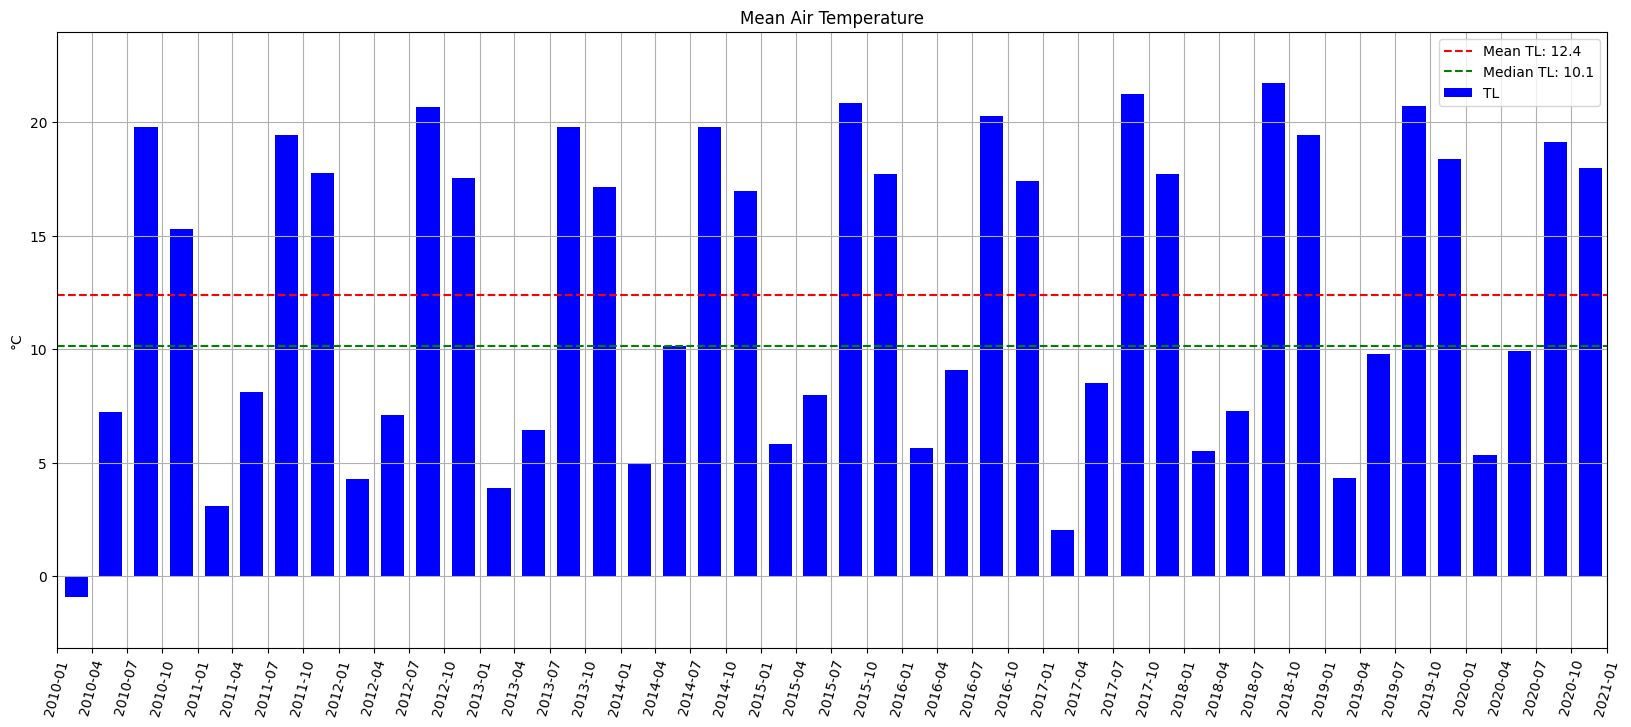

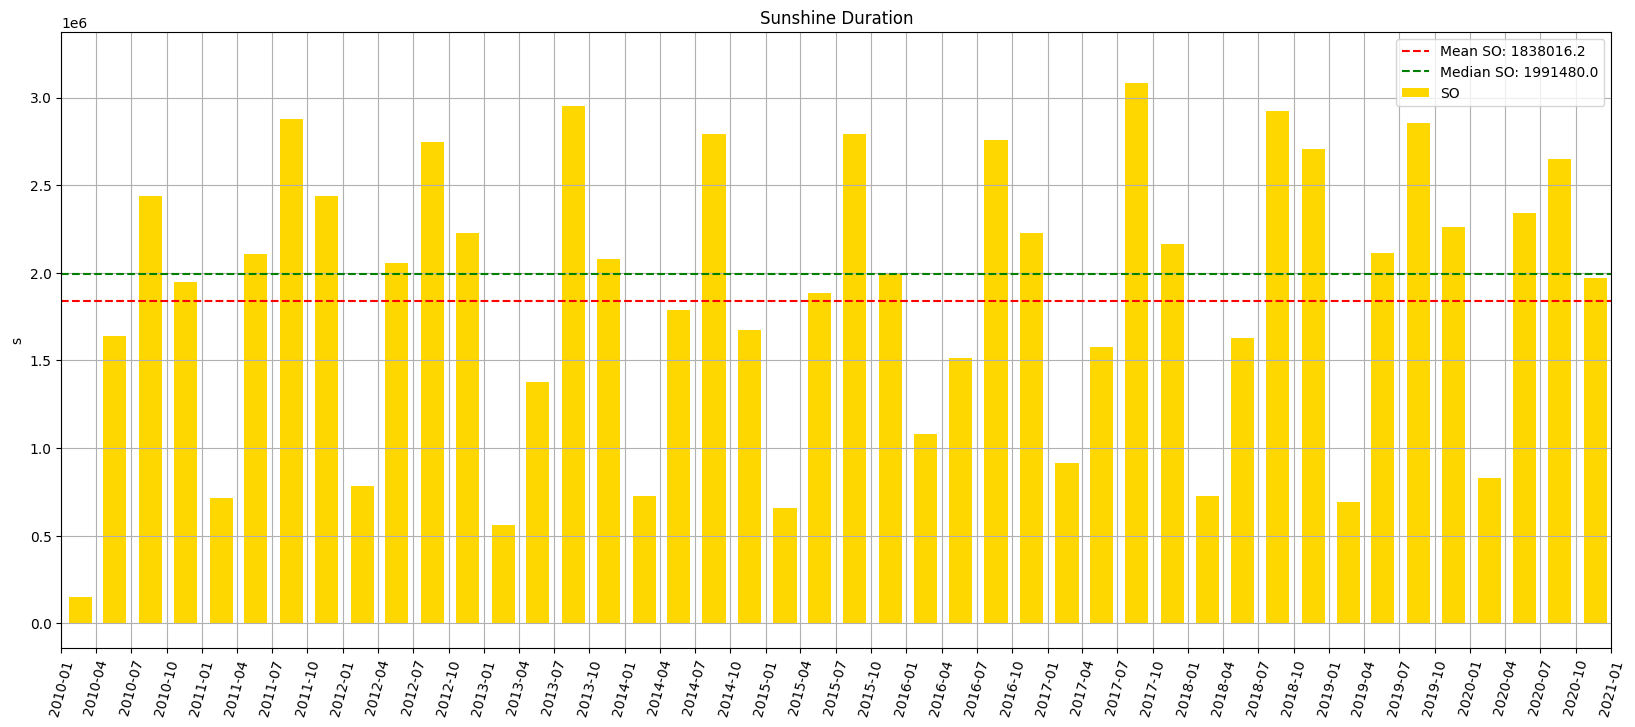

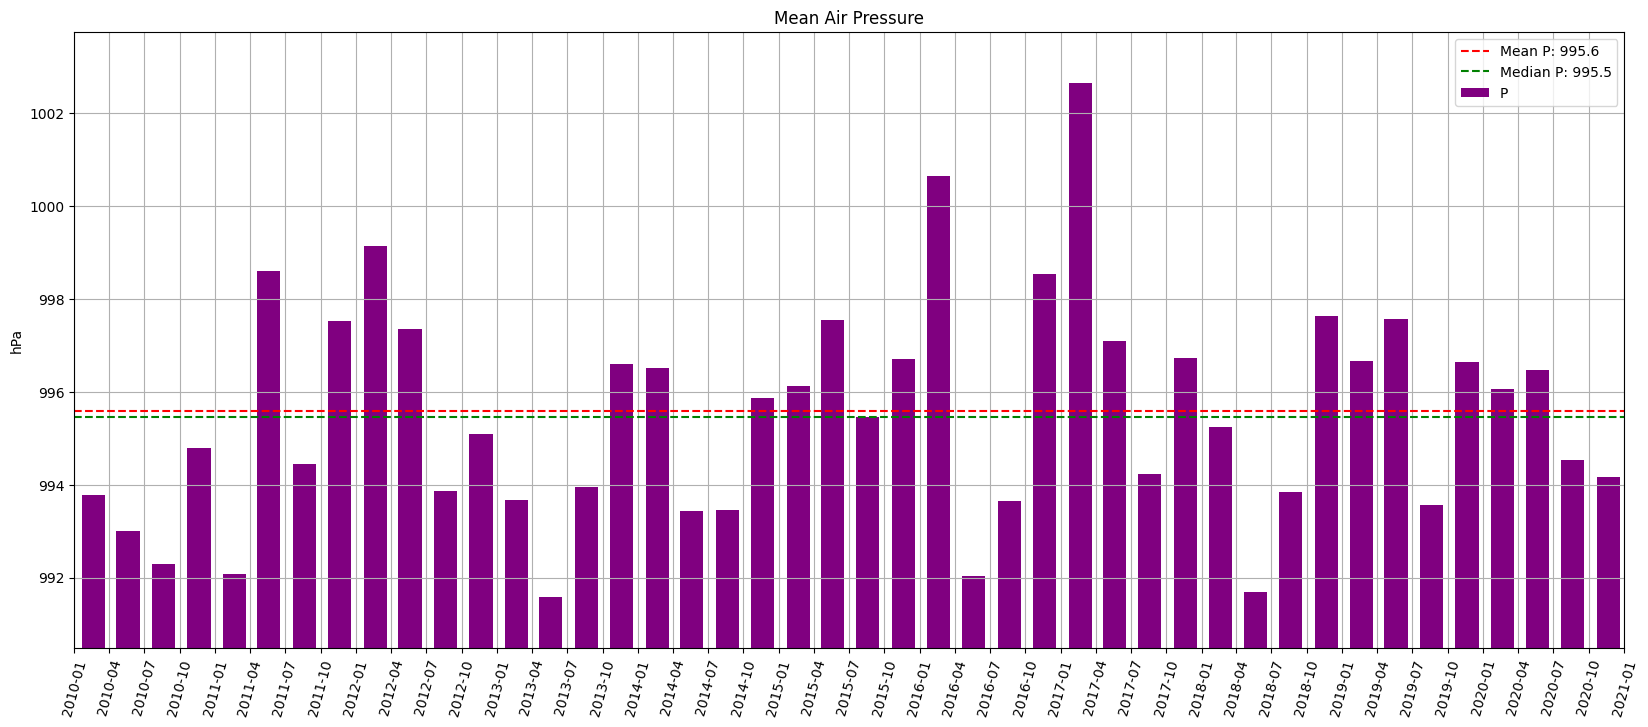

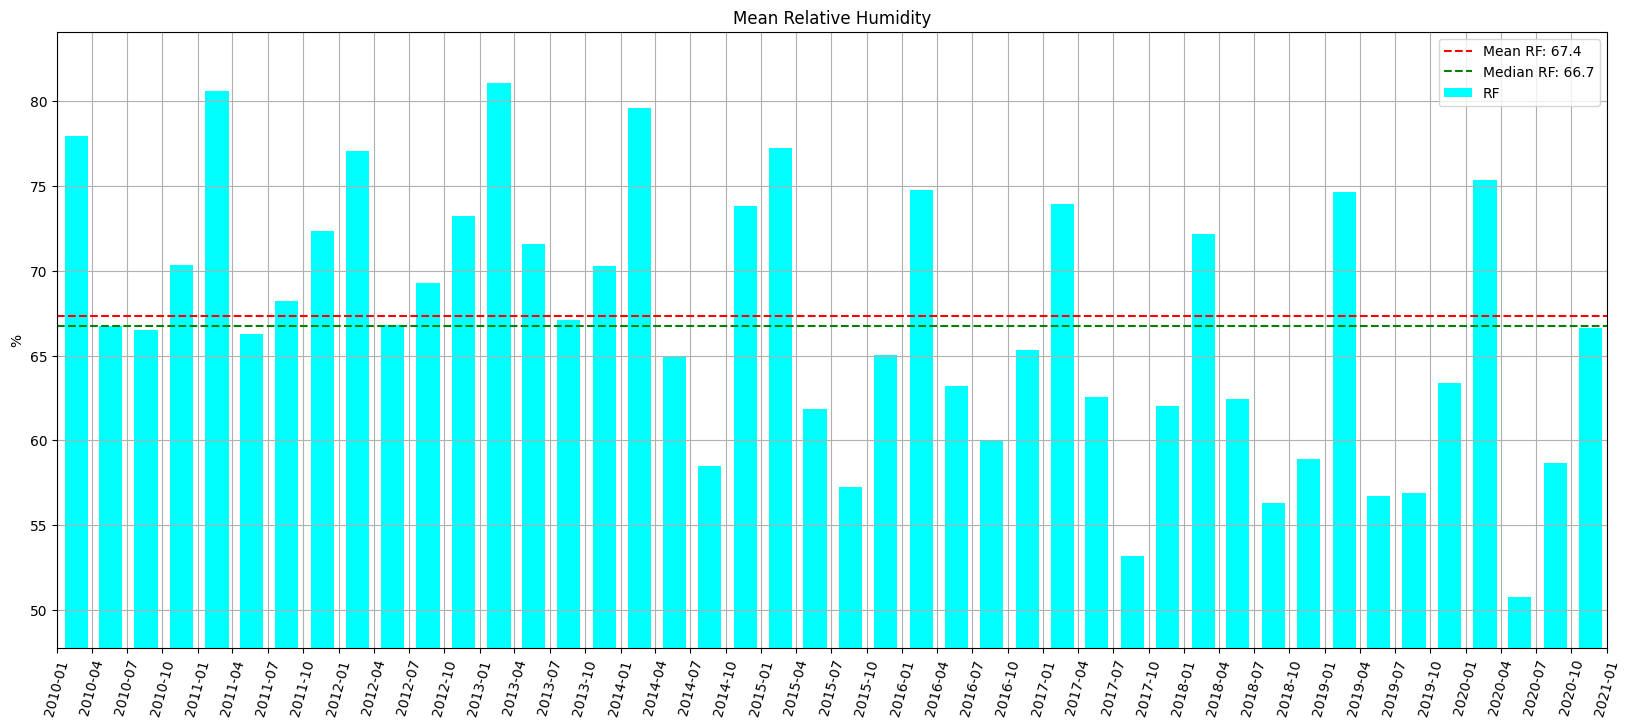

In [2]:
import numpy as np
from matplotlib import dates, pyplot as plt

datetime_format = '%Y-%m-%d %H:%M'
formatter = dates.DateFormatter(datetime_format)


def plot_feature_chart(
        data: pd.DataFrame,
        color: str,
        metric: str,
        agg: str,
        title: str,
        unit_of_measure: str
) -> None:
    agg_func = {metric: agg}
    agg_df: pd.DataFrame = data[metric].resample('3M').agg(agg_func)
    series: pd.Series = agg_df[metric]
    mean_value = series.mean(skipna=True, numeric_only=True)
    median_value = series.median(skipna=True, numeric_only=True)
    # p68 = series.quantile(0.68)
    # p95 = series.quantile(0.95)
    # p99 = series.quantile(0.99)
    plt.figure(figsize=(20, 8))
    index = series.index + pd.DateOffset(days=20)
    plt.bar(index, series, label=metric, color=color, width=60, align='center')
    # plt.set_ylabel(unit_of_measure)
    plt.ylabel(unit_of_measure)
    # plt.set_title(title)
    plt.title(title)
    plt.tick_params(axis='x', rotation=75)
    plt.axhline(mean_value, color='r', linestyle='--', label=f'Mean {metric}: {round(mean_value, 1)}')
    plt.axhline(median_value, color='green', linestyle='--', label=f'Median {metric}: {round(median_value, 1)}')
    # subplot.axhline(p95, color='y', linestyle='--', label=f'P95 {metric}: {round(p95, 1)}')
    # plt.set_major_formatter(date_format)
    ax = plt.gca()
    ax.xaxis.set_major_locator(dates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(dates.DateFormatter('%Y-%m'))
    ax.set_xlim([pd.Timestamp('2010-01-01'), pd.Timestamp('2021-01-01')])

    min_value = series.min()
    max_value = series.max()
    ax.set_ylim(min_value - 0.1 * (max_value - min_value), max_value + 0.1 * (max_value - min_value))

    plt.legend()
    plt.grid(True)
    plt.savefig(f"vienna_20100101_20201231_{metric}.png")


# plt.tight_layout()
# plt.subplots_adjust(hspace=0.6)

plot_feature_chart(df_2010_2021, 'blue', 'TL', 'mean', 'Mean Air Temperature', '°C')
plot_feature_chart(df_2010_2021, 'gold', 'SO', 'sum', 'Sunshine Duration', 's')
plot_feature_chart(df_2010_2021, 'purple', 'P', 'mean', 'Mean Air Pressure', 'hPa')
plot_feature_chart(df_2010_2021, 'cyan', 'RF', 'mean', 'Mean Relative Humidity', '%')

In [3]:
#######################################################
# Base training dataset: Vienna 2010-2019
#######################################################
df_2010_2019: pd.DataFrame = df_2010_2021.loc[df_2010_2021.index.year < 2020]
df_2010_2019 = df_2010_2019.resample('H').agg({'TL': 'mean', 'P': 'mean', 'RF': 'mean', 'SO': 'sum'})
print_df_stats("vienna 2010-2019", df_2010_2019)

vienna 2010-2019
---------------------------------------------------
Start date: 2010-01-01 01:00:00
End date: 2019-12-31 23:00:00
    TL: Min=-13.950000000000001, Mean=12.66363132160193, Median=12.583333333333334, Max=38.78333333333334
    P: Min=955.9833333333332, Mean=995.5006133822163, Median=995.5333333333333, Max=1022.1166666666667
    RF: Min=15.333333333333334, Mean=67.47230367268703, Median=68.83333333333333, Max=100.0
    SO: Min=0.0, Mean=857.6400066935169, Median=0.0, Max=3600.0




In [4]:
#######################################################
# Seasonal datasets
#######################################################
df_winter: pd.DataFrame = df_2010_2019.loc[df_2010_2019.index.month.isin([11, 12, 1, 2])]
print_df_stats("vienna winter", df_winter)
df_spring: pd.DataFrame = df_2010_2019.loc[df_2010_2019.index.month.isin([3, 4, 5, 6])]
print_df_stats("vienna spring", df_spring)
df_summer: pd.DataFrame = df_2010_2019.loc[df_2010_2019.index.month.isin([6, 7, 8, 9])]
print_df_stats("vienna summer", df_summer)
df_autumn: pd.DataFrame = df_2010_2019.loc[df_2010_2019.index.month.isin([9, 10, 11, 12])]
print_df_stats("vienna autumn", df_autumn)

vienna winter
---------------------------------------------------
Start date: 2010-01-01 01:00:00
End date: 2019-12-31 23:00:00
    TL: Min=-13.950000000000001, Mean=4.092070810367341, Median=4.083333333333333, Max=20.75
    P: Min=955.9833333333332, Mean=996.3045995539686, Median=996.7166666666667, Max=1022.1166666666667
    RF: Min=24.5, Mean=75.40349660854392, Median=76.5, Max=100.0
    SO: Min=0.0, Mean=383.0847921794294, Median=0.0, Max=3600.0


vienna spring
---------------------------------------------------
Start date: 2010-03-01 00:00:00
End date: 2019-06-30 23:00:00
    TL: Min=-10.85, Mean=14.7627218047966, Median=14.783333333333333, Max=36.36666666666667
    P: Min=969.1833333333334, Mean=994.2390640179112, Median=994.4166666666666, Max=1015.8166666666666
    RF: Min=17.833333333333332, Mean=61.69526411657558, Median=62.0, Max=100.0
    SO: Min=0.0, Mean=1103.105589708561, Median=0.0, Max=3600.0


vienna summer
---------------------------------------------------
Start date:

In [5]:
#######################################################
# Conditional datasets
#######################################################
# df_day: pd.DataFrame = df_2018_2020.between_time("08:00", "17:00")
# print_df_stats("vienna day", df_day)
# df_night: pd.DataFrame = df_2018_2020.between_time("20:00", "5:00")
# print_df_stats("vienna night", df_night)
high_temp = 25
low_temp = 10

df_high_temperature: pd.DataFrame = df_2010_2019[df_2010_2019['TL'] >= high_temp]
print_df_stats("vienna high temperature", df_high_temperature)
df_medium_temperature: pd.DataFrame = df_2010_2019[(df_2010_2019['TL'] < high_temp) & (df_2010_2019['TL'] > low_temp)]
print_df_stats("vienna medium temperature", df_medium_temperature)
df_low_temperature: pd.DataFrame = df_2010_2019[df_2010_2019['TL'] <= low_temp]
print_df_stats("vienna low temperature", df_low_temperature)

vienna high temperature
---------------------------------------------------
Start date: 2010-04-30 12:00:00
End date: 2019-10-01 14:00:00
    TL: Min=25.0, Mean=28.181377151799687, Median=27.599999999999998, Max=38.78333333333334
    P: Min=977.4333333333334, Mean=993.9773708920188, Median=994.1333333333333, Max=1008.35
    RF: Min=15.333333333333334, Mean=45.57348535658395, Median=45.0, Max=89.16666666666667
    SO: Min=0.0, Mean=2480.272725240331, Median=3339.3333333333335, Max=3600.0


vienna medium temperature
---------------------------------------------------
Start date: 2010-02-24 12:00:00
End date: 2019-12-31 12:00:00
    TL: Min=10.016666666666666, Mean=17.02624063057333, Median=16.95, Max=24.983333333333334
    P: Min=962.4499999999999, Mean=994.9358107282275, Median=995.2333333333332, Max=1017.9333333333334
    RF: Min=17.0, Mean=65.16175652586024, Median=66.0, Max=100.0
    SO: Min=0.0, Mean=971.8511280727355, Median=0.0, Max=3600.0


vienna low temperature
----------------

In [6]:
from common.model_utils import load_model_from_savemodel
from base.model import Model
import os
from base.learning_strategy import RetrainLearningStrategy
from common.model_utils import save_model
from base.training import mse_weighted

models_dir = "models"
base_model: Model = load_model_from_savemodel(os.path.join("base_model", "zamg_vienna_2019_2019_simple_dense"))
learning_strategy = RetrainLearningStrategy()

def train_and_save_model(model_id: str, train_df: pd.DataFrame):
    model = learning_strategy.train_new_model(base_model.model, base_model.metadata, train_df)
    model.metadata.model_id = model_id
    save_model(model, os.path.join(models_dir, model_id))

INFO:root:Initializing configuration: model_dir = models, log_dir = logs, data_dir = data, base_model_id = vienna_2010_2019_simple_dense, training_data_pickle = vienna_20180101_20211231.pickle, log_level = DEBUG
DEBUG:root:Creating new instance of EventLogger
DEBUG:root:Creating new instance of Profiler
DEBUG:root:Saving computation log to logs\profiling.csv
DEBUG:root:Loading model from base_model\zamg_vienna_2019_2019_simple_dense
DEBUG:root:Loading model metadata from base_model\zamg_vienna_2019_2019_simple_dense
DEBUG:root:Created new model with metadata ModelMetadata(model_id=zamg_vienna_2019_2019_simple_dense,features=['TL', 'P', 'RF', 'SO'],periodicity=['day', 'year'],normalization_mean=[14.871072984749457, 995.2527151416123, 59.013888888888886, 1053.897385620915],normalization_std=[8.909478032746524, 7.909731591152052, 15.662470086696423, 1487.361734445307],input_shape=(1, 120, 8),output_shape=(1, 24, 1))


In [7]:
train_and_save_model("vienna_2010_2019_simple_dense", df_2010_2019)

DEBUG:root:Normalized features ['TL', 'P', 'RF', 'SO']
DEBUG:root:Means: [12.66363132160193, 995.5006133822163, 67.47230367268703, 857.6400066935169]
DEBUG:root:Stds: [8.77743399427708, 7.717598433113426, 16.398188616850007, 1375.866506977235]


Epoch 1/100
2735/2735 - 9s - loss: 0.5086 - mean_squared_error: 0.1233 - mean_absolute_error: 0.2415 - root_mean_squared_error: 0.3511 - 9s/epoch - 3ms/step
Epoch 2/100
2735/2735 - 8s - loss: 0.2498 - mean_squared_error: 0.0666 - mean_absolute_error: 0.1887 - root_mean_squared_error: 0.2581 - 8s/epoch - 3ms/step
Epoch 3/100
2735/2735 - 8s - loss: 0.2405 - mean_squared_error: 0.0645 - mean_absolute_error: 0.1847 - root_mean_squared_error: 0.2539 - 8s/epoch - 3ms/step
Epoch 4/100
2735/2735 - 8s - loss: 0.2359 - mean_squared_error: 0.0634 - mean_absolute_error: 0.1826 - root_mean_squared_error: 0.2517 - 8s/epoch - 3ms/step
Epoch 5/100
2735/2735 - 10s - loss: 0.2325 - mean_squared_error: 0.0625 - mean_absolute_error: 0.1811 - root_mean_squared_error: 0.2500 - 10s/epoch - 4ms/step
Epoch 6/100
2735/2735 - 10s - loss: 0.2300 - mean_squared_error: 0.0619 - mean_absolute_error: 0.1800 - root_mean_squared_error: 0.2488 - 10s/epoch - 4ms/step
Epoch 7/100
2735/2735 - 10s - loss: 0.2286 - mean_squa

DEBUG:root:Created new model with metadata ModelMetadata(model_id=78dd6c0a-c0af-42f9-a3da-cdb474626e2b,features=['TL', 'P', 'RF', 'SO'],periodicity=['day', 'year'],normalization_mean=[12.66363132160193, 995.5006133822163, 67.47230367268703, 857.6400066935169],normalization_std=[8.77743399427708, 7.717598433113426, 16.398188616850007, 1375.866506977235],input_shape=(1, 120, 8),output_shape=(1, 24, 1))
DEBUG:root:Saving model vienna_2010_2019_simple_dense as SaveModel to models\vienna_2010_2019_simple_dense


INFO:tensorflow:Assets written to: models\vienna_2010_2019_simple_dense\assets


INFO:tensorflow:Assets written to: models\vienna_2010_2019_simple_dense\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmphw1kbda6\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmphw1kbda6\assets
DEBUG:root:Saving model vienna_2010_2019_simple_dense as TFLite to models\vienna_2010_2019_simple_dense


In [8]:
train_and_save_model("vienna_2010_2019_high_temp_simple_dense", df_high_temperature)

C:\Users\gabri\src\sense-reduce\common\utils.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Day sin'] = np.sin(timestamp_s * (2 * np.pi / day)) / normalization_factor
C:\Users\gabri\src\sense-reduce\common\utils.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Day cos'] = np.cos(timestamp_s * (2 * np.pi / day)) / normalization_factor
C:\Users\gabri\src\sense-reduce\common\utils.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.


Epoch 1/100
229/229 - 1s - loss: 4.8089 - mean_squared_error: 1.0084 - mean_absolute_error: 0.7953 - root_mean_squared_error: 1.0042 - 1s/epoch - 6ms/step
Epoch 2/100
229/229 - 1s - loss: 3.1006 - mean_squared_error: 0.7378 - mean_absolute_error: 0.6797 - root_mean_squared_error: 0.8589 - 599ms/epoch - 3ms/step
Epoch 3/100
229/229 - 1s - loss: 2.7908 - mean_squared_error: 0.6841 - mean_absolute_error: 0.6509 - root_mean_squared_error: 0.8271 - 670ms/epoch - 3ms/step
Epoch 4/100
229/229 - 1s - loss: 2.6452 - mean_squared_error: 0.6585 - mean_absolute_error: 0.6363 - root_mean_squared_error: 0.8115 - 686ms/epoch - 3ms/step
Epoch 5/100
229/229 - 1s - loss: 2.5460 - mean_squared_error: 0.6408 - mean_absolute_error: 0.6256 - root_mean_squared_error: 0.8005 - 684ms/epoch - 3ms/step
Epoch 6/100
229/229 - 1s - loss: 2.4868 - mean_squared_error: 0.6297 - mean_absolute_error: 0.6188 - root_mean_squared_error: 0.7935 - 671ms/epoch - 3ms/step
Epoch 7/100
229/229 - 1s - loss: 2.4487 - mean_squared_

DEBUG:root:Created new model with metadata ModelMetadata(model_id=7a21bf23-715b-4a72-b851-dd278dac5831,features=['TL', 'P', 'RF', 'SO'],periodicity=['day', 'year'],normalization_mean=[28.181377151799687, 993.9773708920188, 45.57348535658395, 2480.272725240331],normalization_std=[2.526331077444863, 4.082409517552135, 11.011220999636288, 1415.9090906510914],input_shape=(1, 120, 8),output_shape=(1, 24, 1))
DEBUG:root:Saving model vienna_2010_2019_high_temp_simple_dense as SaveModel to models\vienna_2010_2019_high_temp_simple_dense


INFO:tensorflow:Assets written to: models\vienna_2010_2019_high_temp_simple_dense\assets


INFO:tensorflow:Assets written to: models\vienna_2010_2019_high_temp_simple_dense\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmpti4nn9w4\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmpti4nn9w4\assets
DEBUG:root:Saving model vienna_2010_2019_high_temp_simple_dense as TFLite to models\vienna_2010_2019_high_temp_simple_dense


In [9]:
train_and_save_model("vienna_2010_2019_medium_temp_simple_dense", df_medium_temperature)

C:\Users\gabri\src\sense-reduce\common\utils.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Day sin'] = np.sin(timestamp_s * (2 * np.pi / day)) / normalization_factor
C:\Users\gabri\src\sense-reduce\common\utils.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Day cos'] = np.cos(timestamp_s * (2 * np.pi / day)) / normalization_factor
C:\Users\gabri\src\sense-reduce\common\utils.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.


Epoch 1/100
1388/1388 - 4s - loss: 1.7076 - mean_squared_error: 0.3962 - mean_absolute_error: 0.4811 - root_mean_squared_error: 0.6295 - 4s/epoch - 3ms/step
Epoch 2/100
1388/1388 - 4s - loss: 1.0809 - mean_squared_error: 0.2721 - mean_absolute_error: 0.3990 - root_mean_squared_error: 0.5216 - 4s/epoch - 3ms/step
Epoch 3/100
1388/1388 - 4s - loss: 1.0270 - mean_squared_error: 0.2623 - mean_absolute_error: 0.3894 - root_mean_squared_error: 0.5121 - 4s/epoch - 3ms/step
Epoch 4/100
1388/1388 - 4s - loss: 1.0001 - mean_squared_error: 0.2572 - mean_absolute_error: 0.3846 - root_mean_squared_error: 0.5071 - 4s/epoch - 3ms/step
Epoch 5/100
1388/1388 - 4s - loss: 0.9842 - mean_squared_error: 0.2540 - mean_absolute_error: 0.3817 - root_mean_squared_error: 0.5040 - 4s/epoch - 3ms/step
Epoch 6/100
1388/1388 - 4s - loss: 0.9724 - mean_squared_error: 0.2516 - mean_absolute_error: 0.3794 - root_mean_squared_error: 0.5016 - 4s/epoch - 3ms/step
Epoch 7/100
1388/1388 - 4s - loss: 0.9636 - mean_squared_e

DEBUG:root:Created new model with metadata ModelMetadata(model_id=f31233ca-06c0-4cfb-af30-1dbfccfc781f,features=['TL', 'P', 'RF', 'SO'],periodicity=['day', 'year'],normalization_mean=[17.02624063057333, 994.9358107282275, 65.16175652586024, 971.8511280727355],normalization_std=[4.121341294459893, 6.267336070779121, 15.596784818828594, 1411.8133027082865],input_shape=(1, 120, 8),output_shape=(1, 24, 1))
DEBUG:root:Saving model vienna_2010_2019_medium_temp_simple_dense as SaveModel to models\vienna_2010_2019_medium_temp_simple_dense


INFO:tensorflow:Assets written to: models\vienna_2010_2019_medium_temp_simple_dense\assets


INFO:tensorflow:Assets written to: models\vienna_2010_2019_medium_temp_simple_dense\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmp6y3u0y6g\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmp6y3u0y6g\assets
DEBUG:root:Saving model vienna_2010_2019_medium_temp_simple_dense as TFLite to models\vienna_2010_2019_medium_temp_simple_dense


In [10]:
train_and_save_model("vienna_2010_2019_low_temp_simple_dense", df_low_temperature)

C:\Users\gabri\src\sense-reduce\common\utils.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Day sin'] = np.sin(timestamp_s * (2 * np.pi / day)) / normalization_factor
C:\Users\gabri\src\sense-reduce\common\utils.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Day cos'] = np.cos(timestamp_s * (2 * np.pi / day)) / normalization_factor
C:\Users\gabri\src\sense-reduce\common\utils.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.


Epoch 1/100
1110/1110 - 4s - loss: 1.3535 - mean_squared_error: 0.3262 - mean_absolute_error: 0.4168 - root_mean_squared_error: 0.5711 - 4s/epoch - 3ms/step
Epoch 2/100
1110/1110 - 3s - loss: 0.7208 - mean_squared_error: 0.1964 - mean_absolute_error: 0.3272 - root_mean_squared_error: 0.4432 - 3s/epoch - 3ms/step
Epoch 3/100
1110/1110 - 4s - loss: 0.6725 - mean_squared_error: 0.1866 - mean_absolute_error: 0.3164 - root_mean_squared_error: 0.4320 - 4s/epoch - 4ms/step
Epoch 4/100
1110/1110 - 3s - loss: 0.6523 - mean_squared_error: 0.1824 - mean_absolute_error: 0.3117 - root_mean_squared_error: 0.4271 - 3s/epoch - 3ms/step
Epoch 5/100
1110/1110 - 3s - loss: 0.6415 - mean_squared_error: 0.1799 - mean_absolute_error: 0.3090 - root_mean_squared_error: 0.4242 - 3s/epoch - 3ms/step
Epoch 6/100
1110/1110 - 3s - loss: 0.6346 - mean_squared_error: 0.1784 - mean_absolute_error: 0.3074 - root_mean_squared_error: 0.4224 - 3s/epoch - 3ms/step
Epoch 7/100
1110/1110 - 4s - loss: 0.6285 - mean_squared_e

DEBUG:root:Created new model with metadata ModelMetadata(model_id=cb60f8e0-0805-4e58-8582-4acd146d8a23,features=['TL', 'P', 'RF', 'SO'],periodicity=['day', 'year'],normalization_mean=[3.966764072401293, 996.5249606480832, 74.93938402171915, 375.57247454203724],normalization_std=[4.134122766355114, 9.588845290519002, 13.004160068747993, 972.197326222518],input_shape=(1, 120, 8),output_shape=(1, 24, 1))
DEBUG:root:Saving model vienna_2010_2019_low_temp_simple_dense as SaveModel to models\vienna_2010_2019_low_temp_simple_dense


INFO:tensorflow:Assets written to: models\vienna_2010_2019_low_temp_simple_dense\assets


INFO:tensorflow:Assets written to: models\vienna_2010_2019_low_temp_simple_dense\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmpmkr3ys9_\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmpmkr3ys9_\assets
DEBUG:root:Saving model vienna_2010_2019_low_temp_simple_dense as TFLite to models\vienna_2010_2019_low_temp_simple_dense


In [11]:
train_and_save_model("vienna_2010_2019_winter_simple_dense", df_winter)

C:\Users\gabri\src\sense-reduce\common\utils.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Day sin'] = np.sin(timestamp_s * (2 * np.pi / day)) / normalization_factor
C:\Users\gabri\src\sense-reduce\common\utils.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Day cos'] = np.cos(timestamp_s * (2 * np.pi / day)) / normalization_factor
C:\Users\gabri\src\sense-reduce\common\utils.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.


Epoch 1/100
897/897 - 7s - loss: 1.5040 - mean_squared_error: 0.3579 - mean_absolute_error: 0.4229 - root_mean_squared_error: 0.5982 - 7s/epoch - 8ms/step
Epoch 2/100
897/897 - 3s - loss: 0.7322 - mean_squared_error: 0.2009 - mean_absolute_error: 0.3177 - root_mean_squared_error: 0.4483 - 3s/epoch - 4ms/step
Epoch 3/100
897/897 - 3s - loss: 0.6754 - mean_squared_error: 0.1896 - mean_absolute_error: 0.3060 - root_mean_squared_error: 0.4355 - 3s/epoch - 3ms/step
Epoch 4/100
897/897 - 3s - loss: 0.6520 - mean_squared_error: 0.1846 - mean_absolute_error: 0.3006 - root_mean_squared_error: 0.4297 - 3s/epoch - 3ms/step
Epoch 5/100
897/897 - 3s - loss: 0.6386 - mean_squared_error: 0.1818 - mean_absolute_error: 0.2975 - root_mean_squared_error: 0.4263 - 3s/epoch - 3ms/step
Epoch 6/100
897/897 - 3s - loss: 0.6282 - mean_squared_error: 0.1795 - mean_absolute_error: 0.2950 - root_mean_squared_error: 0.4236 - 3s/epoch - 4ms/step
Epoch 7/100
897/897 - 3s - loss: 0.6235 - mean_squared_error: 0.1784 -

DEBUG:root:Created new model with metadata ModelMetadata(model_id=c8cf7cf8-a534-4960-9109-b98993427002,features=['TL', 'P', 'RF', 'SO'],periodicity=['day', 'year'],normalization_mean=[4.092070810367341, 996.3045995539686, 75.40349660854392, 383.0847921794294],normalization_std=[4.939921691581684, 9.912124150239485, 12.980450219124494, 985.2672719616282],input_shape=(1, 120, 8),output_shape=(1, 24, 1))
DEBUG:root:Saving model vienna_2010_2019_winter_simple_dense as SaveModel to models\vienna_2010_2019_winter_simple_dense


INFO:tensorflow:Assets written to: models\vienna_2010_2019_winter_simple_dense\assets


INFO:tensorflow:Assets written to: models\vienna_2010_2019_winter_simple_dense\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmp0w1hmnmb\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmp0w1hmnmb\assets
DEBUG:root:Saving model vienna_2010_2019_winter_simple_dense as TFLite to models\vienna_2010_2019_winter_simple_dense


In [12]:
train_and_save_model("vienna_2010_2019_spring_simple_dense", df_spring)

C:\Users\gabri\src\sense-reduce\common\utils.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Day sin'] = np.sin(timestamp_s * (2 * np.pi / day)) / normalization_factor
C:\Users\gabri\src\sense-reduce\common\utils.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Day cos'] = np.cos(timestamp_s * (2 * np.pi / day)) / normalization_factor
C:\Users\gabri\src\sense-reduce\common\utils.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.


Epoch 1/100
911/911 - 3s - loss: 1.5086 - mean_squared_error: 0.3435 - mean_absolute_error: 0.4112 - root_mean_squared_error: 0.5861 - 3s/epoch - 4ms/step
Epoch 2/100
911/911 - 3s - loss: 0.5766 - mean_squared_error: 0.1503 - mean_absolute_error: 0.2757 - root_mean_squared_error: 0.3877 - 3s/epoch - 3ms/step
Epoch 3/100
911/911 - 3s - loss: 0.5393 - mean_squared_error: 0.1434 - mean_absolute_error: 0.2660 - root_mean_squared_error: 0.3787 - 3s/epoch - 3ms/step
Epoch 4/100
911/911 - 3s - loss: 0.5200 - mean_squared_error: 0.1398 - mean_absolute_error: 0.2608 - root_mean_squared_error: 0.3739 - 3s/epoch - 3ms/step
Epoch 5/100
911/911 - 3s - loss: 0.5065 - mean_squared_error: 0.1367 - mean_absolute_error: 0.2573 - root_mean_squared_error: 0.3698 - 3s/epoch - 3ms/step
Epoch 6/100
911/911 - 3s - loss: 0.4935 - mean_squared_error: 0.1338 - mean_absolute_error: 0.2546 - root_mean_squared_error: 0.3658 - 3s/epoch - 4ms/step
Epoch 7/100
911/911 - 3s - loss: 0.4874 - mean_squared_error: 0.1321 -

DEBUG:root:Created new model with metadata ModelMetadata(model_id=b8e36a2e-c476-4607-8efa-69d5b175b585,features=['TL', 'P', 'RF', 'SO'],periodicity=['day', 'year'],normalization_mean=[14.7627218047966, 994.2390640179112, 61.69526411657558, 1103.105589708561],normalization_std=[7.045603985491137, 7.093891293744925, 16.302387669399607, 1476.6811724582515],input_shape=(1, 120, 8),output_shape=(1, 24, 1))
DEBUG:root:Saving model vienna_2010_2019_spring_simple_dense as SaveModel to models\vienna_2010_2019_spring_simple_dense


INFO:tensorflow:Assets written to: models\vienna_2010_2019_spring_simple_dense\assets


INFO:tensorflow:Assets written to: models\vienna_2010_2019_spring_simple_dense\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmpizdjgh99\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmpizdjgh99\assets
DEBUG:root:Saving model vienna_2010_2019_spring_simple_dense as TFLite to models\vienna_2010_2019_spring_simple_dense


In [13]:
train_and_save_model("vienna_2010_2019_summer_simple_dense", df_summer)

C:\Users\gabri\src\sense-reduce\common\utils.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Day sin'] = np.sin(timestamp_s * (2 * np.pi / day)) / normalization_factor
C:\Users\gabri\src\sense-reduce\common\utils.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Day cos'] = np.cos(timestamp_s * (2 * np.pi / day)) / normalization_factor
C:\Users\gabri\src\sense-reduce\common\utils.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.


Epoch 1/100
911/911 - 4s - loss: 1.6306 - mean_squared_error: 0.3839 - mean_absolute_error: 0.4574 - root_mean_squared_error: 0.6196 - 4s/epoch - 4ms/step
Epoch 2/100
911/911 - 6s - loss: 0.8179 - mean_squared_error: 0.2104 - mean_absolute_error: 0.3392 - root_mean_squared_error: 0.4587 - 6s/epoch - 7ms/step
Epoch 3/100
911/911 - 3s - loss: 0.7790 - mean_squared_error: 0.2025 - mean_absolute_error: 0.3303 - root_mean_squared_error: 0.4500 - 3s/epoch - 3ms/step
Epoch 4/100
911/911 - 3s - loss: 0.7616 - mean_squared_error: 0.1987 - mean_absolute_error: 0.3263 - root_mean_squared_error: 0.4458 - 3s/epoch - 3ms/step
Epoch 5/100
911/911 - 3s - loss: 0.7508 - mean_squared_error: 0.1960 - mean_absolute_error: 0.3237 - root_mean_squared_error: 0.4427 - 3s/epoch - 4ms/step
Epoch 6/100
911/911 - 3s - loss: 0.7443 - mean_squared_error: 0.1944 - mean_absolute_error: 0.3220 - root_mean_squared_error: 0.4409 - 3s/epoch - 4ms/step
Epoch 7/100
911/911 - 3s - loss: 0.7377 - mean_squared_error: 0.1929 -

DEBUG:root:Created new model with metadata ModelMetadata(model_id=47a6f8e8-506d-4e23-9cb7-620d849d9a9c,features=['TL', 'P', 'RF', 'SO'],periodicity=['day', 'year'],normalization_mean=[21.30856386612022, 995.1191695127504, 61.808794398907104, 1259.2530396174864],normalization_std=[5.0932503826481685, 4.928081825377782, 16.389880614617, 1523.2938742660863],input_shape=(1, 120, 8),output_shape=(1, 24, 1))
DEBUG:root:Saving model vienna_2010_2019_summer_simple_dense as SaveModel to models\vienna_2010_2019_summer_simple_dense


INFO:tensorflow:Assets written to: models\vienna_2010_2019_summer_simple_dense\assets


INFO:tensorflow:Assets written to: models\vienna_2010_2019_summer_simple_dense\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmp3tc07zd9\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmp3tc07zd9\assets
DEBUG:root:Saving model vienna_2010_2019_summer_simple_dense as TFLite to models\vienna_2010_2019_summer_simple_dense


In [14]:
train_and_save_model("vienna_2010_2019_autumn_simple_dense", df_autumn)

C:\Users\gabri\src\sense-reduce\common\utils.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Day sin'] = np.sin(timestamp_s * (2 * np.pi / day)) / normalization_factor
C:\Users\gabri\src\sense-reduce\common\utils.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Day cos'] = np.cos(timestamp_s * (2 * np.pi / day)) / normalization_factor
C:\Users\gabri\src\sense-reduce\common\utils.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.


Epoch 1/100
911/911 - 4s - loss: 1.2095 - mean_squared_error: 0.2775 - mean_absolute_error: 0.3610 - root_mean_squared_error: 0.5268 - 4s/epoch - 5ms/step
Epoch 2/100
911/911 - 4s - loss: 0.5141 - mean_squared_error: 0.1381 - mean_absolute_error: 0.2540 - root_mean_squared_error: 0.3716 - 4s/epoch - 4ms/step
Epoch 3/100
911/911 - 3s - loss: 0.4779 - mean_squared_error: 0.1307 - mean_absolute_error: 0.2444 - root_mean_squared_error: 0.3616 - 3s/epoch - 3ms/step
Epoch 4/100
911/911 - 3s - loss: 0.4615 - mean_squared_error: 0.1270 - mean_absolute_error: 0.2391 - root_mean_squared_error: 0.3564 - 3s/epoch - 3ms/step
Epoch 5/100
911/911 - 3s - loss: 0.4514 - mean_squared_error: 0.1245 - mean_absolute_error: 0.2355 - root_mean_squared_error: 0.3528 - 3s/epoch - 3ms/step
Epoch 6/100
911/911 - 3s - loss: 0.4437 - mean_squared_error: 0.1226 - mean_absolute_error: 0.2331 - root_mean_squared_error: 0.3501 - 3s/epoch - 3ms/step
Epoch 7/100
911/911 - 3s - loss: 0.4378 - mean_squared_error: 0.1214 -

DEBUG:root:Created new model with metadata ModelMetadata(model_id=0c1b1426-dc19-42c1-92a8-5667619e4e31,features=['TL', 'P', 'RF', 'SO'],periodicity=['day', 'year'],normalization_mean=[10.228206967213113, 997.061593237705, 73.92084471766847, 583.2985997267759],normalization_std=[6.676101595171294, 8.260341418881689, 14.030153702407677, 1192.401994483303],input_shape=(1, 120, 8),output_shape=(1, 24, 1))
DEBUG:root:Saving model vienna_2010_2019_autumn_simple_dense as SaveModel to models\vienna_2010_2019_autumn_simple_dense


INFO:tensorflow:Assets written to: models\vienna_2010_2019_autumn_simple_dense\assets


INFO:tensorflow:Assets written to: models\vienna_2010_2019_autumn_simple_dense\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmpmm12236x\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmpmm12236x\assets
DEBUG:root:Saving model vienna_2010_2019_autumn_simple_dense as TFLite to models\vienna_2010_2019_autumn_simple_dense


In [15]:
#######################################################
# Base training dataset: Vienna 2019
#######################################################
df_2019_2019: pd.DataFrame = df_2010_2021.loc[df_2010_2021.index.year == 2019]
df_2019_2019 = df_2019_2019.resample('H').agg({'TL': 'mean', 'P': 'mean', 'RF': 'mean', 'SO': 'sum'})
df_2019_2019.to_pickle("data/vienna_20190101_20191231.pickle")
print_df_stats("vienna 2010-2019", df_2019_2019)

vienna 2010-2019
---------------------------------------------------
Start date: 2019-01-01 00:00:00
End date: 2019-12-31 23:00:00
    TL: Min=-5.866666666666667, Mean=13.535315829528159, Median=12.583333333333334, Max=37.800000000000004
    P: Min=965.0166666666668, Mean=994.8208352359208, Median=994.5500000000001, Max=1022.1166666666667
    RF: Min=16.166666666666668, Mean=62.60146499238965, Median=64.0, Max=96.0
    SO: Min=0.0, Mean=916.0503424657534, Median=0.0, Max=3600.0




In [16]:
#######################################################
# Conditional datasets
#######################################################
high_temp = 25
low_temp = 10

df_high_temperature: pd.DataFrame = df_2019_2019[df_2019_2019['TL'] >= high_temp]
print_df_stats("vienna high temperature", df_high_temperature)
df_medium_temperature: pd.DataFrame = df_2019_2019[(df_2019_2019['TL'] < high_temp) & (df_2019_2019['TL'] > low_temp)]
print_df_stats("vienna medium temperature", df_medium_temperature)
df_low_temperature: pd.DataFrame = df_2019_2019[df_2019_2019['TL'] <= low_temp]
print_df_stats("vienna low temperature", df_low_temperature)

vienna high temperature
---------------------------------------------------
Start date: 2019-04-25 12:00:00
End date: 2019-10-01 14:00:00
    TL: Min=25.0, Mean=28.178915434205535, Median=27.650000000000002, Max=37.800000000000004
    P: Min=979.7666666666668, Mean=994.4194728858552, Median=994.1166666666667, Max=1008.35
    RF: Min=16.166666666666668, Mean=43.3839590443686, Median=43.333333333333336, Max=70.66666666666667
    SO: Min=0.0, Mean=2351.6408797876375, Median=3090.3333333333335, Max=3600.0


vienna medium temperature
---------------------------------------------------
Start date: 2019-01-17 10:00:00
End date: 2019-12-31 12:00:00
    TL: Min=10.016666666666667, Mean=16.8871806135149, Median=16.716666666666665, Max=24.983333333333334
    P: Min=969.25, Mean=994.3243209605389, Median=994.1999999999999, Max=1014.8666666666667
    RF: Min=17.833333333333332, Mean=60.918991141372, Median=61.666666666666664, Max=95.66666666666667
    SO: Min=0.0, Mean=1031.8380554945456, Median=0.

In [17]:
train_and_save_model("vienna_2019_2019_simple_dense", df_2019_2019)

DEBUG:root:Normalized features ['TL', 'P', 'RF', 'SO']
DEBUG:root:Means: [13.535315829528159, 994.8208352359208, 62.60146499238965, 916.0503424657534]
DEBUG:root:Stds: [8.34207752228285, 8.29884485027671, 15.941960305194401, 1404.2561584262046]


Epoch 1/100
270/270 - 2s - loss: 2.3019 - mean_squared_error: 0.5058 - mean_absolute_error: 0.5276 - root_mean_squared_error: 0.7112 - 2s/epoch - 9ms/step
Epoch 2/100
270/270 - 1s - loss: 0.5740 - mean_squared_error: 0.1411 - mean_absolute_error: 0.2925 - root_mean_squared_error: 0.3757 - 1s/epoch - 4ms/step
Epoch 3/100
270/270 - 2s - loss: 0.4090 - mean_squared_error: 0.1029 - mean_absolute_error: 0.2470 - root_mean_squared_error: 0.3208 - 2s/epoch - 8ms/step
Epoch 4/100
270/270 - 2s - loss: 0.3586 - mean_squared_error: 0.0917 - mean_absolute_error: 0.2306 - root_mean_squared_error: 0.3028 - 2s/epoch - 6ms/step
Epoch 5/100
270/270 - 2s - loss: 0.3370 - mean_squared_error: 0.0872 - mean_absolute_error: 0.2232 - root_mean_squared_error: 0.2953 - 2s/epoch - 6ms/step
Epoch 6/100
270/270 - 1s - loss: 0.3246 - mean_squared_error: 0.0847 - mean_absolute_error: 0.2189 - root_mean_squared_error: 0.2911 - 1s/epoch - 4ms/step
Epoch 7/100
270/270 - 1s - loss: 0.3159 - mean_squared_error: 0.0830 -

DEBUG:root:Created new model with metadata ModelMetadata(model_id=e53c7837-aec9-4692-b79b-71183dee1013,features=['TL', 'P', 'RF', 'SO'],periodicity=['day', 'year'],normalization_mean=[13.535315829528159, 994.8208352359208, 62.60146499238965, 916.0503424657534],normalization_std=[8.34207752228285, 8.29884485027671, 15.941960305194401, 1404.2561584262046],input_shape=(1, 120, 8),output_shape=(1, 24, 1))
DEBUG:root:Saving model vienna_2019_2019_simple_dense as SaveModel to models\vienna_2019_2019_simple_dense


INFO:tensorflow:Assets written to: models\vienna_2019_2019_simple_dense\assets


INFO:tensorflow:Assets written to: models\vienna_2019_2019_simple_dense\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmpi_c2lfjc\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmpi_c2lfjc\assets
DEBUG:root:Saving model vienna_2019_2019_simple_dense as TFLite to models\vienna_2019_2019_simple_dense


In [18]:
train_and_save_model("vienna_2019_2019_high_temp_simple_dense", df_high_temperature)

C:\Users\gabri\src\sense-reduce\common\utils.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Day sin'] = np.sin(timestamp_s * (2 * np.pi / day)) / normalization_factor
C:\Users\gabri\src\sense-reduce\common\utils.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Day cos'] = np.cos(timestamp_s * (2 * np.pi / day)) / normalization_factor
C:\Users\gabri\src\sense-reduce\common\utils.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.


Epoch 1/100
23/23 - 2s - loss: 9.6409 - mean_squared_error: 1.8201 - mean_absolute_error: 1.0847 - root_mean_squared_error: 1.3491 - 2s/epoch - 79ms/step
Epoch 2/100
23/23 - 0s - loss: 7.1239 - mean_squared_error: 1.3889 - mean_absolute_error: 0.9529 - root_mean_squared_error: 1.1785 - 157ms/epoch - 7ms/step
Epoch 3/100
23/23 - 0s - loss: 6.0064 - mean_squared_error: 1.2050 - mean_absolute_error: 0.8915 - root_mean_squared_error: 1.0977 - 158ms/epoch - 7ms/step
Epoch 4/100
23/23 - 0s - loss: 5.4011 - mean_squared_error: 1.1075 - mean_absolute_error: 0.8563 - root_mean_squared_error: 1.0524 - 187ms/epoch - 8ms/step
Epoch 5/100
23/23 - 0s - loss: 5.0147 - mean_squared_error: 1.0457 - mean_absolute_error: 0.8329 - root_mean_squared_error: 1.0226 - 169ms/epoch - 7ms/step
Epoch 6/100
23/23 - 0s - loss: 4.7159 - mean_squared_error: 0.9990 - mean_absolute_error: 0.8143 - root_mean_squared_error: 0.9995 - 174ms/epoch - 8ms/step
Epoch 7/100
23/23 - 0s - loss: 4.4691 - mean_squared_error: 0.9604

DEBUG:root:Created new model with metadata ModelMetadata(model_id=ef5640f7-d1c1-424f-8f33-242de879b959,features=['TL', 'P', 'RF', 'SO'],periodicity=['day', 'year'],normalization_mean=[28.178915434205535, 994.4194728858552, 43.3839590443686, 2351.6408797876375],normalization_std=[2.472231842438545, 4.287146058155737, 10.235603902265913, 1433.0305615677537],input_shape=(1, 120, 8),output_shape=(1, 24, 1))
DEBUG:root:Saving model vienna_2019_2019_high_temp_simple_dense as SaveModel to models\vienna_2019_2019_high_temp_simple_dense


INFO:tensorflow:Assets written to: models\vienna_2019_2019_high_temp_simple_dense\assets


INFO:tensorflow:Assets written to: models\vienna_2019_2019_high_temp_simple_dense\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmpionrpy0d\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmpionrpy0d\assets
DEBUG:root:Saving model vienna_2019_2019_high_temp_simple_dense as TFLite to models\vienna_2019_2019_high_temp_simple_dense


In [19]:
train_and_save_model("vienna_2019_2019_medium_temp_simple_dense", df_medium_temperature)

C:\Users\gabri\src\sense-reduce\common\utils.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Day sin'] = np.sin(timestamp_s * (2 * np.pi / day)) / normalization_factor
C:\Users\gabri\src\sense-reduce\common\utils.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Day cos'] = np.cos(timestamp_s * (2 * np.pi / day)) / normalization_factor
C:\Users\gabri\src\sense-reduce\common\utils.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.


Epoch 1/100
138/138 - 2s - loss: 4.8019 - mean_squared_error: 0.9634 - mean_absolute_error: 0.7985 - root_mean_squared_error: 0.9815 - 2s/epoch - 13ms/step
Epoch 2/100
138/138 - 0s - loss: 1.9856 - mean_squared_error: 0.4578 - mean_absolute_error: 0.5392 - root_mean_squared_error: 0.6766 - 393ms/epoch - 3ms/step
Epoch 3/100
138/138 - 0s - loss: 1.4185 - mean_squared_error: 0.3373 - mean_absolute_error: 0.4575 - root_mean_squared_error: 0.5808 - 376ms/epoch - 3ms/step
Epoch 4/100
138/138 - 0s - loss: 1.2557 - mean_squared_error: 0.3028 - mean_absolute_error: 0.4294 - root_mean_squared_error: 0.5503 - 394ms/epoch - 3ms/step
Epoch 5/100
138/138 - 0s - loss: 1.1777 - mean_squared_error: 0.2863 - mean_absolute_error: 0.4158 - root_mean_squared_error: 0.5351 - 361ms/epoch - 3ms/step
Epoch 6/100
138/138 - 0s - loss: 1.1304 - mean_squared_error: 0.2762 - mean_absolute_error: 0.4071 - root_mean_squared_error: 0.5255 - 377ms/epoch - 3ms/step
Epoch 7/100
138/138 - 0s - loss: 1.0959 - mean_squared

DEBUG:root:Created new model with metadata ModelMetadata(model_id=ecbc4124-dbf5-44d0-9048-427582c6d1e6,features=['TL', 'P', 'RF', 'SO'],periodicity=['day', 'year'],normalization_mean=[16.8871806135149, 994.3243209605389, 60.918991141372, 1031.8380554945456],normalization_std=[4.391734171909592, 7.087672138079945, 15.696952834321031, 1450.8490277073602],input_shape=(1, 120, 8),output_shape=(1, 24, 1))
DEBUG:root:Saving model vienna_2019_2019_medium_temp_simple_dense as SaveModel to models\vienna_2019_2019_medium_temp_simple_dense


INFO:tensorflow:Assets written to: models\vienna_2019_2019_medium_temp_simple_dense\assets


INFO:tensorflow:Assets written to: models\vienna_2019_2019_medium_temp_simple_dense\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmpifotei8r\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmpifotei8r\assets
DEBUG:root:Saving model vienna_2019_2019_medium_temp_simple_dense as TFLite to models\vienna_2019_2019_medium_temp_simple_dense


In [20]:
train_and_save_model("vienna_2019_2019_low_temp_simple_dense", df_low_temperature)

C:\Users\gabri\src\sense-reduce\common\utils.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Day sin'] = np.sin(timestamp_s * (2 * np.pi / day)) / normalization_factor
C:\Users\gabri\src\sense-reduce\common\utils.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Day cos'] = np.cos(timestamp_s * (2 * np.pi / day)) / normalization_factor
C:\Users\gabri\src\sense-reduce\common\utils.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.


Epoch 1/100
100/100 - 2s - loss: 5.1409 - mean_squared_error: 1.0619 - mean_absolute_error: 0.8235 - root_mean_squared_error: 1.0305 - 2s/epoch - 17ms/step
Epoch 2/100
100/100 - 0s - loss: 2.5525 - mean_squared_error: 0.6043 - mean_absolute_error: 0.6102 - root_mean_squared_error: 0.7773 - 284ms/epoch - 3ms/step
Epoch 3/100
100/100 - 0s - loss: 1.6073 - mean_squared_error: 0.4171 - mean_absolute_error: 0.4971 - root_mean_squared_error: 0.6458 - 336ms/epoch - 3ms/step
Epoch 4/100
100/100 - 0s - loss: 1.4121 - mean_squared_error: 0.3717 - mean_absolute_error: 0.4656 - root_mean_squared_error: 0.6096 - 316ms/epoch - 3ms/step
Epoch 5/100
100/100 - 0s - loss: 1.3259 - mean_squared_error: 0.3513 - mean_absolute_error: 0.4511 - root_mean_squared_error: 0.5927 - 361ms/epoch - 4ms/step
Epoch 6/100
100/100 - 0s - loss: 1.2643 - mean_squared_error: 0.3364 - mean_absolute_error: 0.4402 - root_mean_squared_error: 0.5800 - 346ms/epoch - 3ms/step
Epoch 7/100
100/100 - 0s - loss: 1.2137 - mean_squared

DEBUG:root:Created new model with metadata ModelMetadata(model_id=b9bbb5bf-f9ab-4cde-8e96-4db1a4a226d3,features=['TL', 'P', 'RF', 'SO'],periodicity=['day', 'year'],normalization_mean=[5.081961137820513, 995.6061197916667, 69.97901642628206, 378.47055288461536],normalization_std=[3.4203248142408653, 10.331385923070215, 12.183368892394935, 957.9363296551004],input_shape=(1, 120, 8),output_shape=(1, 24, 1))
DEBUG:root:Saving model vienna_2019_2019_low_temp_simple_dense as SaveModel to models\vienna_2019_2019_low_temp_simple_dense


INFO:tensorflow:Assets written to: models\vienna_2019_2019_low_temp_simple_dense\assets


INFO:tensorflow:Assets written to: models\vienna_2019_2019_low_temp_simple_dense\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmpp0m1uvri\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmpp0m1uvri\assets
DEBUG:root:Saving model vienna_2019_2019_low_temp_simple_dense as TFLite to models\vienna_2019_2019_low_temp_simple_dense
